# WNBA Draft Fit Predictor — Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load predictions
predictions = pd.read_csv("../data/processed/predictions_2026.csv")
rookies_df = pd.read_csv("../data/processed/rookies_clean.csv")

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")

print("Ready!")

Ready!


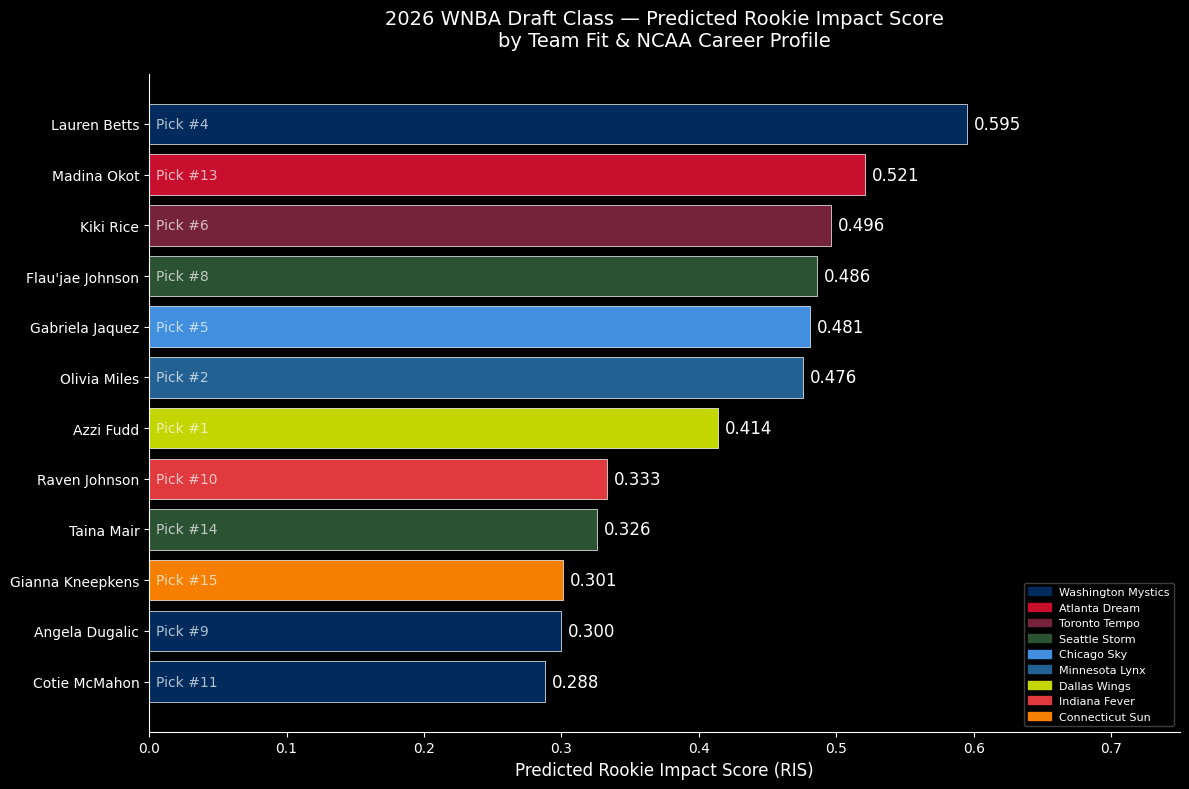

Saved!


In [4]:
# Sort by predicted RIS
plot_df = predictions[['player', 'wnba_team', 'draft_pick', 'predicted_RIS']].sort_values('predicted_RIS', ascending=True)

# Team colors
team_colors = {
    'Washington Mystics': '#002B5C',
    'Atlanta Dream': '#C8102E',
    'Toronto Tempo': '#75233B',
    'Seattle Storm': '#2C5234',
    'Chicago Sky': '#418FDE',
    'Minnesota Lynx': '#236192',
    'Dallas Wings': '#C4D600',
    'Indiana Fever': '#E03A3E',
    'Connecticut Sun': '#F77F00',
}

colors = [team_colors.get(team, '#888888') for team in plot_df['wnba_team']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(plot_df['player'], plot_df['predicted_RIS'], color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, plot_df['predicted_RIS']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=12, color='white')

# Add draft pick labels
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(0.005, i, f'Pick #{int(row["draft_pick"])}',
            va='center', fontsize=10, color='white', alpha=0.7)

ax.set_xlabel('Predicted Rookie Impact Score (RIS)', fontsize=12, color='white')
ax.set_title('2026 WNBA Draft Class — Predicted Rookie Impact Score\nby Team Fit & NCAA Career Profile', 
             fontsize=14, color='white', pad=20)
ax.set_xlim(0, 0.75)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=color, label=team) 
                  for team, color in team_colors.items() 
                  if team in plot_df['wnba_team'].values]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/predicted_ris_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

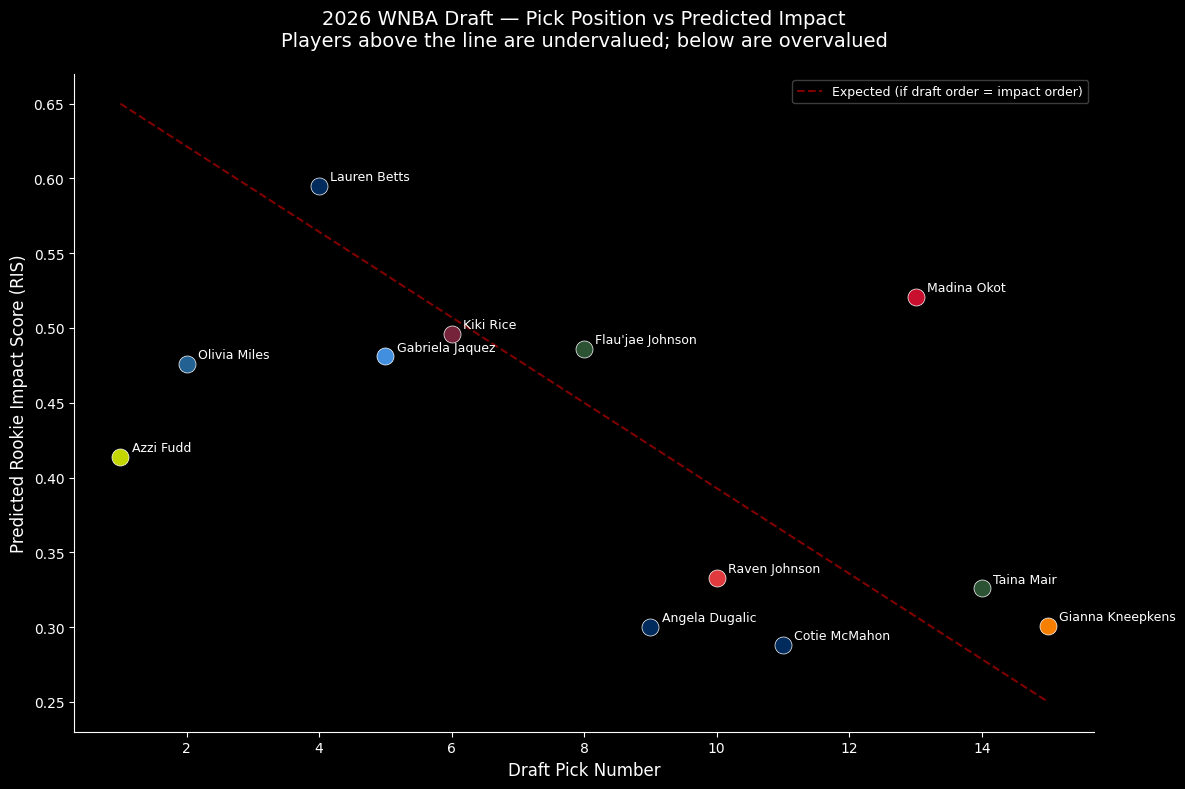

Saved!


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each player
for _, row in predictions.iterrows():
    color = team_colors.get(row['wnba_team'], '#888888')
    ax.scatter(row['draft_pick'], row['predicted_RIS'], 
               color=color, s=150, zorder=5, edgecolors='white', linewidth=0.5)
    ax.annotate(row['player'], 
                (row['draft_pick'], row['predicted_RIS']),
                textcoords="offset points", xytext=(8, 4),
                fontsize=9, color='white')

# Add diagonal reference line (perfect draft = pick rank matches RIS rank)
# Higher pick number should mean lower RIS if teams drafted perfectly
x = np.linspace(1, 15, 100)
y = 0.65 - (x - 1) * (0.65 - 0.25) / 14
ax.plot(x, y, '--', color='red', alpha=0.5, label='Expected (if draft order = impact order)')

ax.set_xlabel('Draft Pick Number', fontsize=12, color='white')
ax.set_ylabel('Predicted Rookie Impact Score (RIS)', fontsize=12, color='white')
ax.set_title('2026 WNBA Draft — Pick Position vs Predicted Impact\nPlayers above the line are undervalued; below are overvalued', 
             fontsize=14, color='white', pad=20)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/draft_position_vs_ris.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

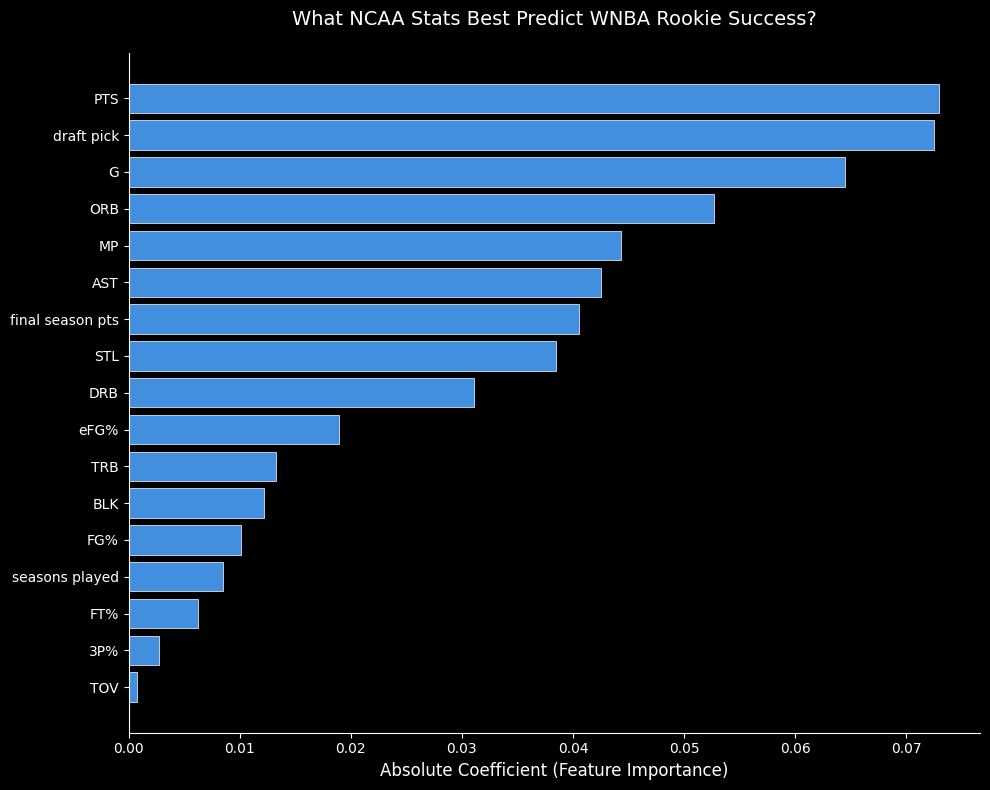

Saved!


In [7]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Reload training data
rookies_clean = pd.read_csv("../data/processed/rookies_clean.csv")
rookie_ncaa = pd.read_csv("../data/processed/rookie_ncaa_features.csv")

# Recalculate RIS
ris_features = ['wnba_games', 'wnba_mpg', 'wnba_ppg', 'wnba_rpg', 'wnba_apg', 'wnba_ws40']
scaler_ris = MinMaxScaler()
rookies_scaled = rookies_clean.copy()
rookies_scaled[ris_features] = scaler_ris.fit_transform(rookies_clean[ris_features])
rookies_clean['RIS'] = (
    0.20 * rookies_scaled['wnba_games'] +
    0.20 * rookies_scaled['wnba_mpg'] +
    0.20 * rookies_scaled['wnba_ppg'] +
    0.15 * rookies_scaled['wnba_rpg'] +
    0.10 * rookies_scaled['wnba_apg'] +
    0.15 * rookies_scaled['wnba_ws40']
).round(3)

training_df = rookies_clean.merge(rookie_ncaa, on='player', how='inner')
training_df['draft_pick'] = pd.to_numeric(training_df['draft_pick'], errors='coerce')

feature_cols = ['avg_G', 'avg_MP', 'avg_FG%', 'avg_3P%', 'avg_FT%', 
                'avg_ORB', 'avg_DRB', 'avg_TRB', 'avg_AST', 'avg_STL', 
                'avg_BLK', 'avg_TOV', 'avg_PTS', 'avg_eFG%',
                'seasons_played', 'final_season_pts', 'draft_pick']

X = training_df[feature_cols]
y = training_df['RIS']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = Ridge(alpha=1.0)
model.fit(X_scaled, y)

# Plot feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': np.abs(model.coef_)
}).sort_values('coefficient', ascending=True)

# Clean up feature names for display
feature_importance['feature'] = feature_importance['feature'].str.replace('avg_', '').str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(feature_importance['feature'], feature_importance['coefficient'],
               color='#418FDE', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Absolute Coefficient (Feature Importance)', fontsize=12, color='white')
ax.set_title('What NCAA Stats Best Predict WNBA Rookie Success?', 
             fontsize=14, color='white', pad=20)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

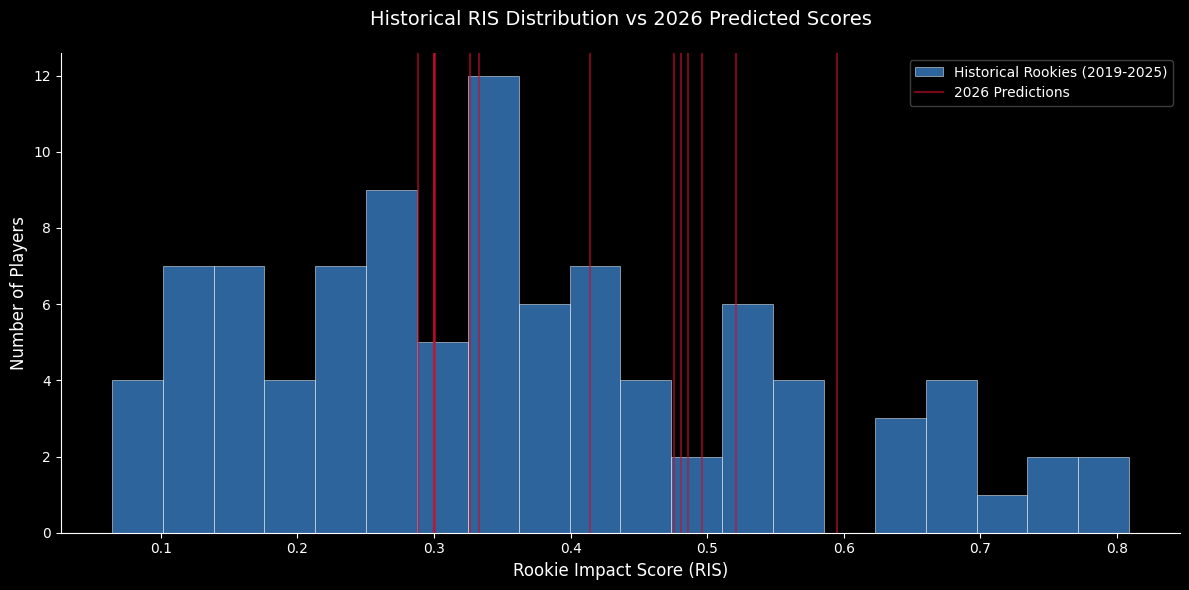

Saved!


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(rookies_clean['RIS'], bins=20, color='#418FDE', alpha=0.7, 
        label='Historical Rookies (2019-2025)', edgecolor='white', linewidth=0.5)

for _, row in predictions.iterrows():
    ax.axvline(row['predicted_RIS'], color='#C8102E', alpha=0.6, linewidth=1.5)

ax.axvline(predictions['predicted_RIS'].iloc[0], color='#C8102E', 
           alpha=0.6, linewidth=1.5, label='2026 Predictions')

ax.set_xlabel('Rookie Impact Score (RIS)', fontsize=12, color='white')
ax.set_ylabel('Number of Players', fontsize=12, color='white')
ax.set_title('Historical RIS Distribution vs 2026 Predicted Scores', 
             fontsize=14, color='white', pad=20)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/ris_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")